# 05. Compare mutational spectra

This notebook builds DB-weighted mutational spectra for groups prepared in `03_prepare_spectrum_groups.ipynb` and weighted in `04_add_spectrum_weights.ipynb`.

The input table is:

```text
../results/spectrum_groups/spectrum_groups_with_weights_T95.tsv
```

The key weight is:

```text
combined_db_spectrum_weight
```

It is calculated in the previous step as:

```text
combined_db_spectrum_weight =
    max(gnomAD_count + Helix_count, 1)
    /
    ((gnomAD_total + Helix_total) × ref_base_count)
```

Here `ref_base_count` is the number of reference nucleotides of the same type as the mutated base. For example, `A>G` is normalized by the number of `A` nucleotides, and `C>T` is normalized by the number of `C` nucleotides.

In this notebook we do **not** divide by `ref_base_count` again. We only sum the already normalized weights inside each group.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

In [2]:
# ============================================================
# Paths and deterministic 192-component order
# ============================================================

INPUT_PATH = Path("../results/spectrum_groups/spectrum_groups_with_weights_192_T95.tsv")

OUTPUT_DIR = Path("../results/mutation_spectra")
FIGURE_DIR = Path("../results/figures/mutation_spectra_192_T95")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SPECTRUM_OUTPUT = OUTPUT_DIR / "spectrum_weighted_frequencies_192_T95.tsv"

WEIGHT_COL = "combined_db_spectrum_weight"
GROUP_COL = "spectrum_group_primary_T95"

substitution_order_12 = [
    "A>C", "A>G", "A>T",
    "C>A", "C>G", "C>T",
    "G>A", "G>C", "G>T",
    "T>A", "T>C", "T>G",
]
substitution_order_192 = [
    f"{left}[{substitution}]{right}"
    for left in "ACGT"
    for substitution in substitution_order_12
    for right in "ACGT"
]

assert len(substitution_order_192) == 192
assert len(set(substitution_order_192)) == 192

## Load spectrum-group table

At this stage each row is one possible mtDNA SNV. The table already contains the group assignment from Isolation Forest and the population-derived spectrum weight from gnomAD + Helix.

In [3]:
df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)
work = df.copy()

required_cols = {
    "variant_id", "substitution_type_192", "is_valid_snv_substitution",
    GROUP_COL, WEIGHT_COL,
}
missing_cols = sorted(required_cols.difference(work.columns))
if missing_cols:
    raise ValueError(f"Missing required 192-spectrum columns: {missing_cols}")

work = work[work["is_valid_snv_substitution"] == 1].copy()
work = work[work[GROUP_COL] != "exclude"].copy()
work[WEIGHT_COL] = pd.to_numeric(work[WEIGHT_COL], errors="coerce").fillna(0.0)

unknown_categories = sorted(
    set(work["substitution_type_192"].dropna()) - set(substitution_order_192)
)
if unknown_categories:
    raise ValueError(f"Unknown 192-component categories: {unknown_categories[:10]}")

print("Input shape:", df.shape)
print("Analysis table shape:", work.shape)
print("Categories represented:", work["substitution_type_192"].nunique(), "/ 192")
print("\nGroups:")
print(work[GROUP_COL].value_counts(dropna=False))
print("\nWeight summary:")
print(work[WEIGHT_COL].describe())

Input shape: (49698, 60)
Analysis table shape: (49558, 60)
Categories represented: 192 / 192

Groups:
spectrum_group_primary_T95
unlabeled_out_of_neutral_domain_T95    27643
expanded_neutral_like_T95              21915
Name: count, dtype: int64

Weight summary:
count    4.955800e+04
mean     2.185496e-06
std      5.475528e-05
min      6.348875e-09
25%      9.455127e-09
50%      1.290455e-08
75%      3.329158e-08
max      6.055904e-03
Name: combined_db_spectrum_weight, dtype: float64


## Calculate weighted mutational spectrum

For each group `g` and substitution type `t`:

```text
weighted_sum(g, t) =
    Σ combined_db_spectrum_weight_i
```

where the sum is taken over all variants `i` that belong to group `g` and substitution type `t`.

Then we normalize the weights inside each group:

```text
weighted_frequency(g, t) =
    weighted_sum(g, t) / Σ weighted_sum(g, all substitution types)
```

This gives a 12-component DB-weighted mutational spectrum for each group.

In [4]:
def compute_weighted_spectrum(data, group_col, weight_col):
    spectrum = (
        data
        .groupby([group_col, "substitution_type_192"], as_index=False)
        .agg(
            n_variants=("variant_id", "count"),
            weighted_sum=(weight_col, "sum"),
        )
        .rename(columns={
            group_col: "group_name",
            "substitution_type_192": "substitution_type",
        })
    )

    all_groups = sorted(spectrum["group_name"].dropna().unique())
    complete_index = pd.MultiIndex.from_product(
        [all_groups, substitution_order_192],
        names=["group_name", "substitution_type"],
    )
    spectrum = (
        spectrum
        .set_index(["group_name", "substitution_type"])
        .reindex(complete_index)
        .reset_index()
    )
    spectrum["n_variants"] = spectrum["n_variants"].fillna(0).astype(int)
    spectrum["weighted_sum"] = spectrum["weighted_sum"].fillna(0.0)
    spectrum["total_weight"] = (
        spectrum.groupby("group_name")["weighted_sum"].transform("sum")
    )
    if (spectrum["total_weight"] <= 0).any():
        raise ValueError("At least one group has zero total spectrum weight.")
    spectrum["weighted_frequency"] = spectrum["weighted_sum"] / spectrum["total_weight"]
    spectrum.insert(0, "group_col", group_col)
    spectrum["weight_col"] = weight_col
    return spectrum


spectrum = compute_weighted_spectrum(work, GROUP_COL, WEIGHT_COL)
spectrum.to_csv(SPECTRUM_OUTPUT, sep="\t", index=False)

assert spectrum.groupby("group_name").size().eq(192).all()
assert np.allclose(spectrum.groupby("group_name")["weighted_frequency"].sum(), 1.0)

print("Saved:", SPECTRUM_OUTPUT)
display(spectrum.head(24))

Saved: ..\results\mutation_spectra\spectrum_weighted_frequencies_192_T95.tsv


,group_col,group_name,substitution_type,n_variants,weighted_sum,total_weight,weighted_frequency,weight_col
0,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]A,179,0.000020,0.085699,0.000238,combined_db_spectrum_weight
1,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]C,160,0.000073,0.085699,0.000855,combined_db_spectrum_weight
2,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]G,94,0.000005,0.085699,0.000064,combined_db_spectrum_weight
3,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]T,114,0.000001,0.085699,0.000016,combined_db_spectrum_weight
4,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]A,238,0.000790,0.085699,0.009222,combined_db_spectrum_weight
5,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]C,306,0.002050,0.085699,0.023918,combined_db_spectrum_weight
6,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]G,112,0.000534,0.085699,0.006234,combined_db_spectrum_weight
7,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]T,220,0.000855,0.085699,0.009980,combined_db_spectrum_weight
8,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>T]A,176,0.000004,0.085699,0.000044,combined_db_spectrum_weight
9,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>T]C,168,0.000004,0.085699,0.000044,combined_db_spectrum_weight


## Plot functions

The plots below use `weighted_frequency` as the spectrum value. This is the final DB-weighted spectrum.

In [5]:
group_label_map = {
    "expanded_neutral_like_T95": "Expanded neutral-like",
    "strict_expanded_neutral_like_T95": "Strict expanded neutral-like",
    "unlabeled_out_of_neutral_domain_T95": "Out-of-neutral-domain",
    "known_neutral_reference": "Known neutral reference",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
    "unlabeled_neutral_like_T95": "Unlabeled neutral-like",
}


def safe_filename(text):
    return (
        str(text)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(">", "to")
        .replace(":", "_")
    )


def plot_single_spectrum(spectrum_df, group_name, output_dir=FIGURE_DIR):
    plot_df = (
        spectrum_df[spectrum_df["group_name"] == group_name]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    x = np.arange(len(substitution_order_192))
    y = plot_df["weighted_frequency"].values

    label = group_label_map.get(group_name, group_name)
    n_variants = int(plot_df["n_variants"].sum())

    plt.figure(figsize=(32, 7))
    plt.bar(x, y)
    plt.xticks(x, substitution_order_192, rotation=90, ha="center", fontsize=5)
    plt.ylabel("DB-weighted spectrum frequency")
    plt.xlabel("Substitution type")
    plt.title(f"{label} n={n_variants}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_{safe_filename(group_name)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_two_group_comparison(spectrum_df, group_1, group_2, output_dir=FIGURE_DIR):
    df1 = (
        spectrum_df[spectrum_df["group_name"] == group_1]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    df2 = (
        spectrum_df[spectrum_df["group_name"] == group_2]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    x = np.arange(len(substitution_order_192))
    width = 0.4

    label_1 = group_label_map.get(group_1, group_1)
    label_2 = group_label_map.get(group_2, group_2)

    plt.figure(figsize=(32, 7))
    plt.bar(x - width / 2, df1["weighted_frequency"].values, width=width, label=label_1)
    plt.bar(x + width / 2, df2["weighted_frequency"].values, width=width, label=label_2)
    plt.xticks(x, substitution_order_192, rotation=90, ha="center", fontsize=5)
    plt.ylabel("DB-weighted spectrum frequency")
    plt.xlabel("Substitution type")
    plt.title("DB-weighted mutational spectrum comparison")
    plt.legend()
    plt.tight_layout()

    output_path = output_dir / f"spectrum_comparison_{safe_filename(group_1)}_vs_{safe_filename(group_2)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_spectrum_difference(spectrum_df, reference_group, comparison_group, output_dir=FIGURE_DIR):
    ref = (
        spectrum_df[spectrum_df["group_name"] == reference_group]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    comp = (
        spectrum_df[spectrum_df["group_name"] == comparison_group]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    diff = comp["weighted_frequency"].values - ref["weighted_frequency"].values

    x = np.arange(len(substitution_order_192))

    label_ref = group_label_map.get(reference_group, reference_group)
    label_comp = group_label_map.get(comparison_group, comparison_group)

    plt.figure(figsize=(32, 7))
    plt.bar(x, diff)
    plt.axhline(0, linewidth=1)
    plt.xticks(x, substitution_order_192, rotation=90, ha="center", fontsize=5)
    plt.ylabel("Difference in DB-weighted frequency")
    plt.xlabel("Substitution type")
    plt.title(f"{label_comp} minus {label_ref}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_difference_{safe_filename(comparison_group)}_minus_{safe_filename(reference_group)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path

## Main plots

The main comparison is between the expanded neutral-like group and variants outside the neutral domain.

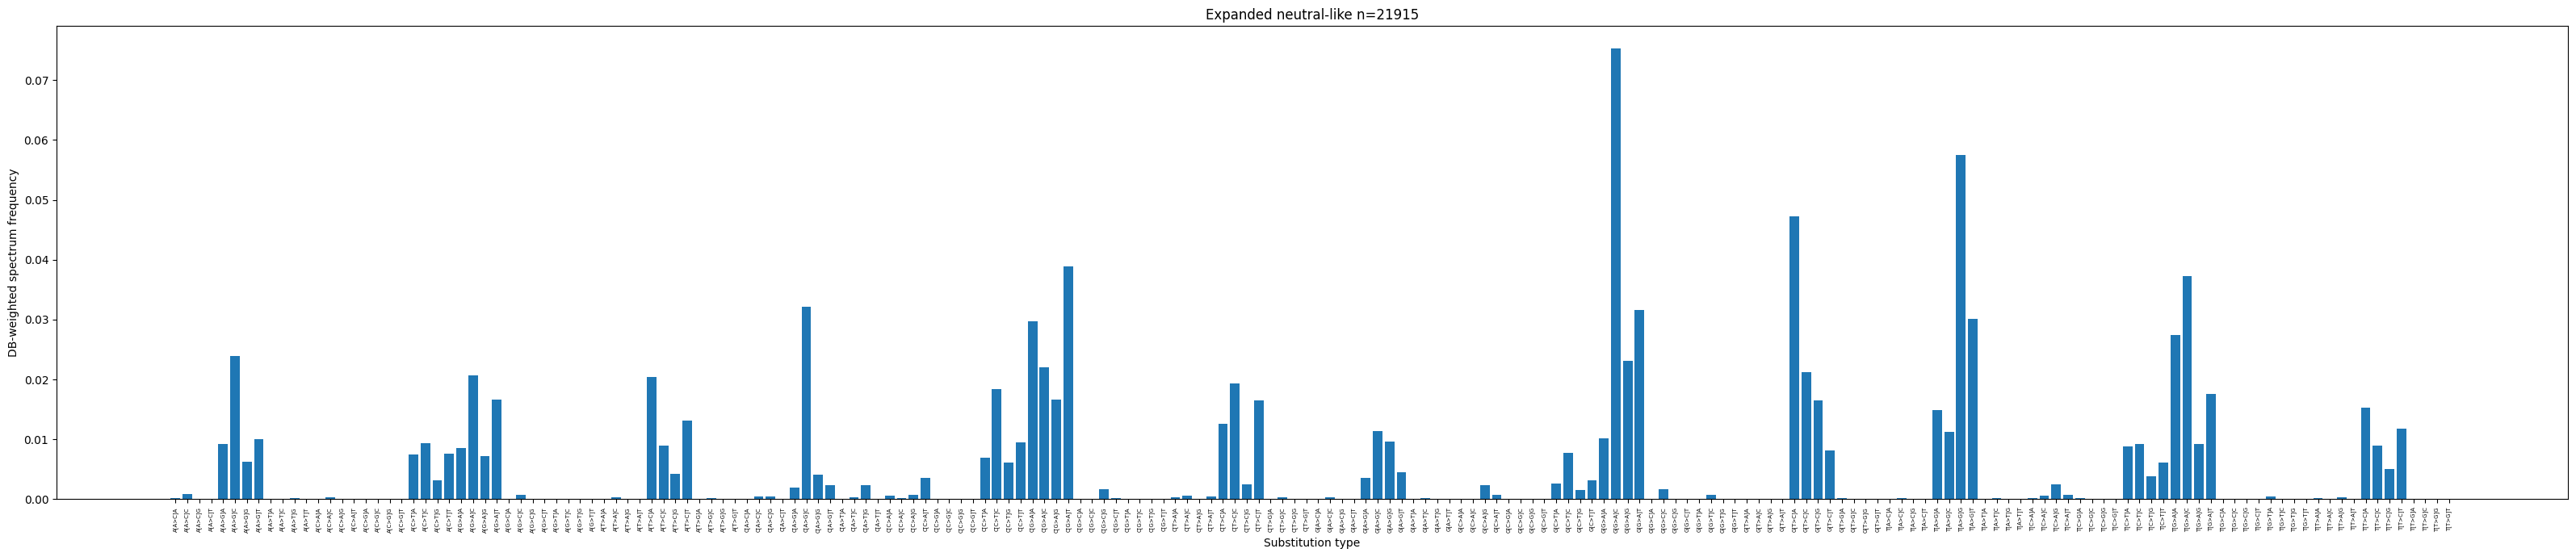

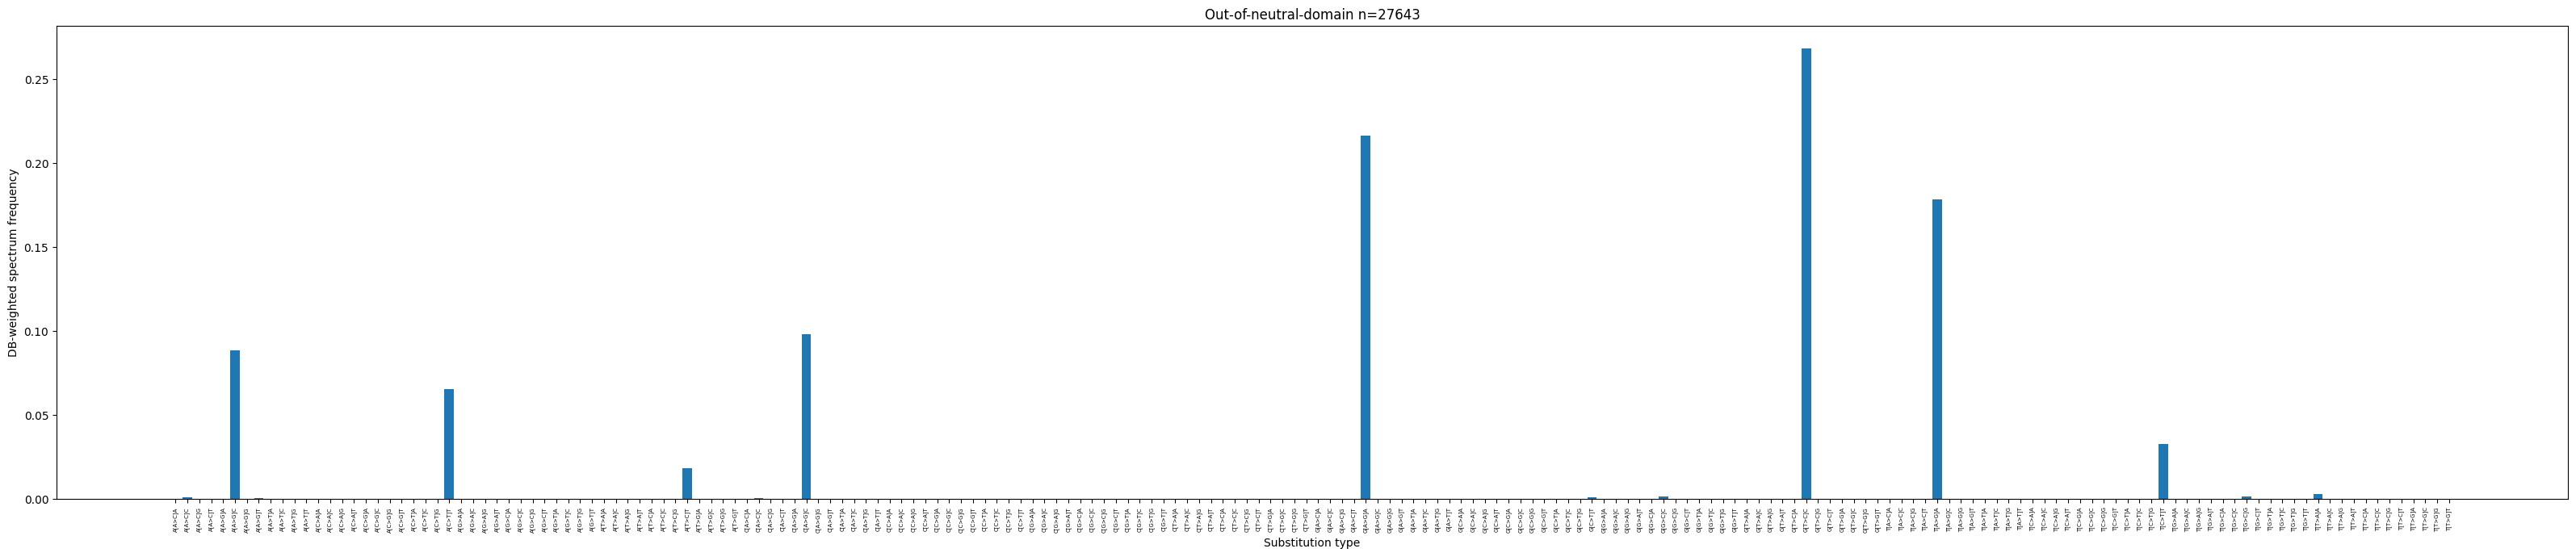

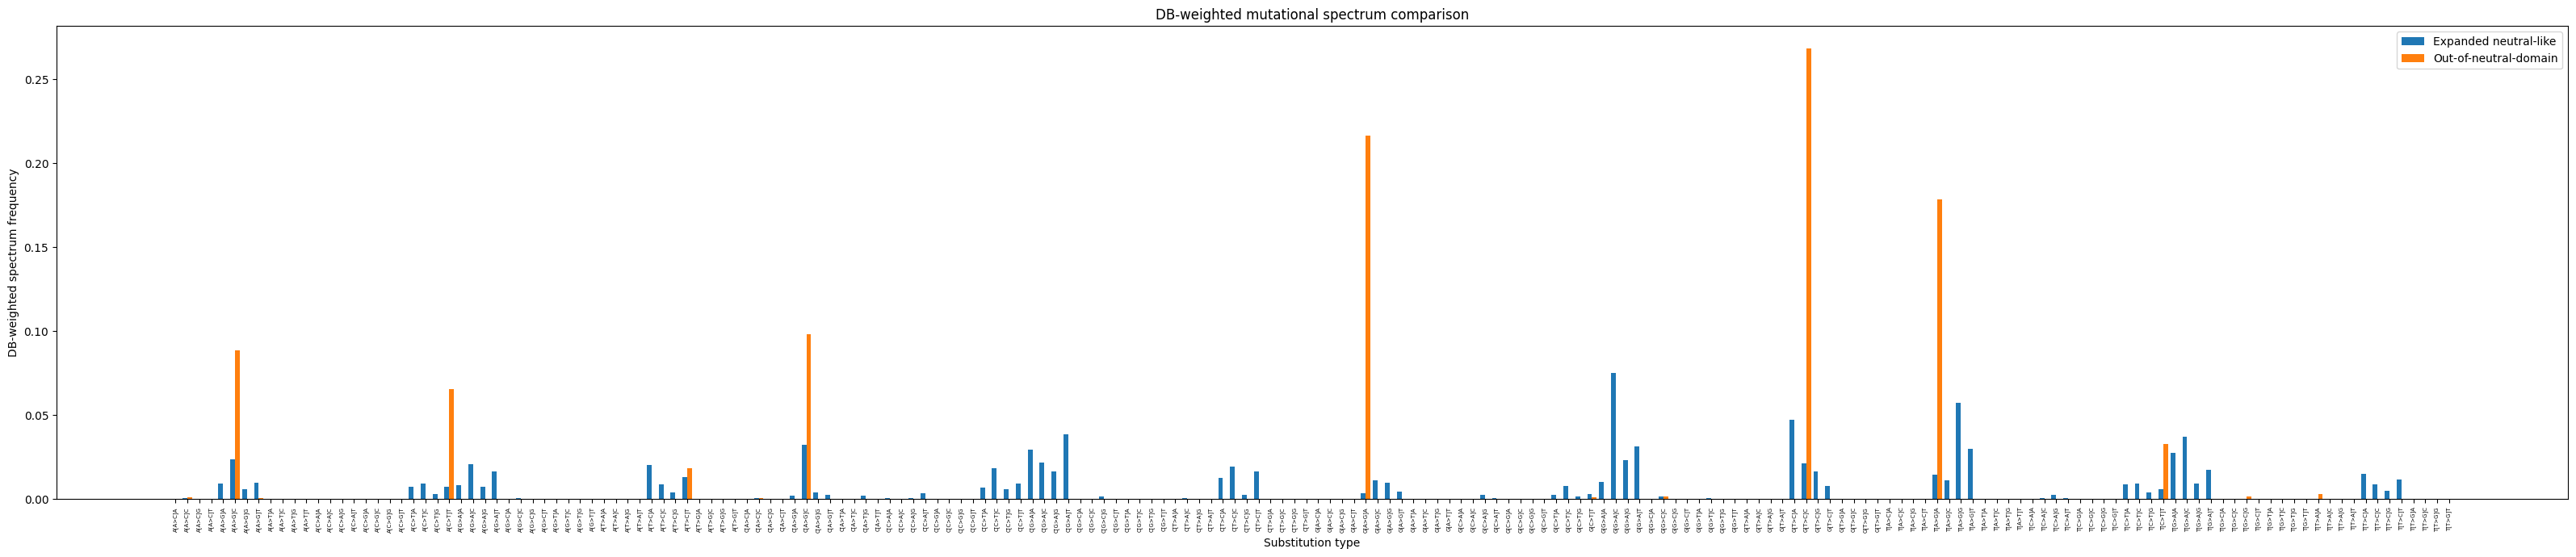

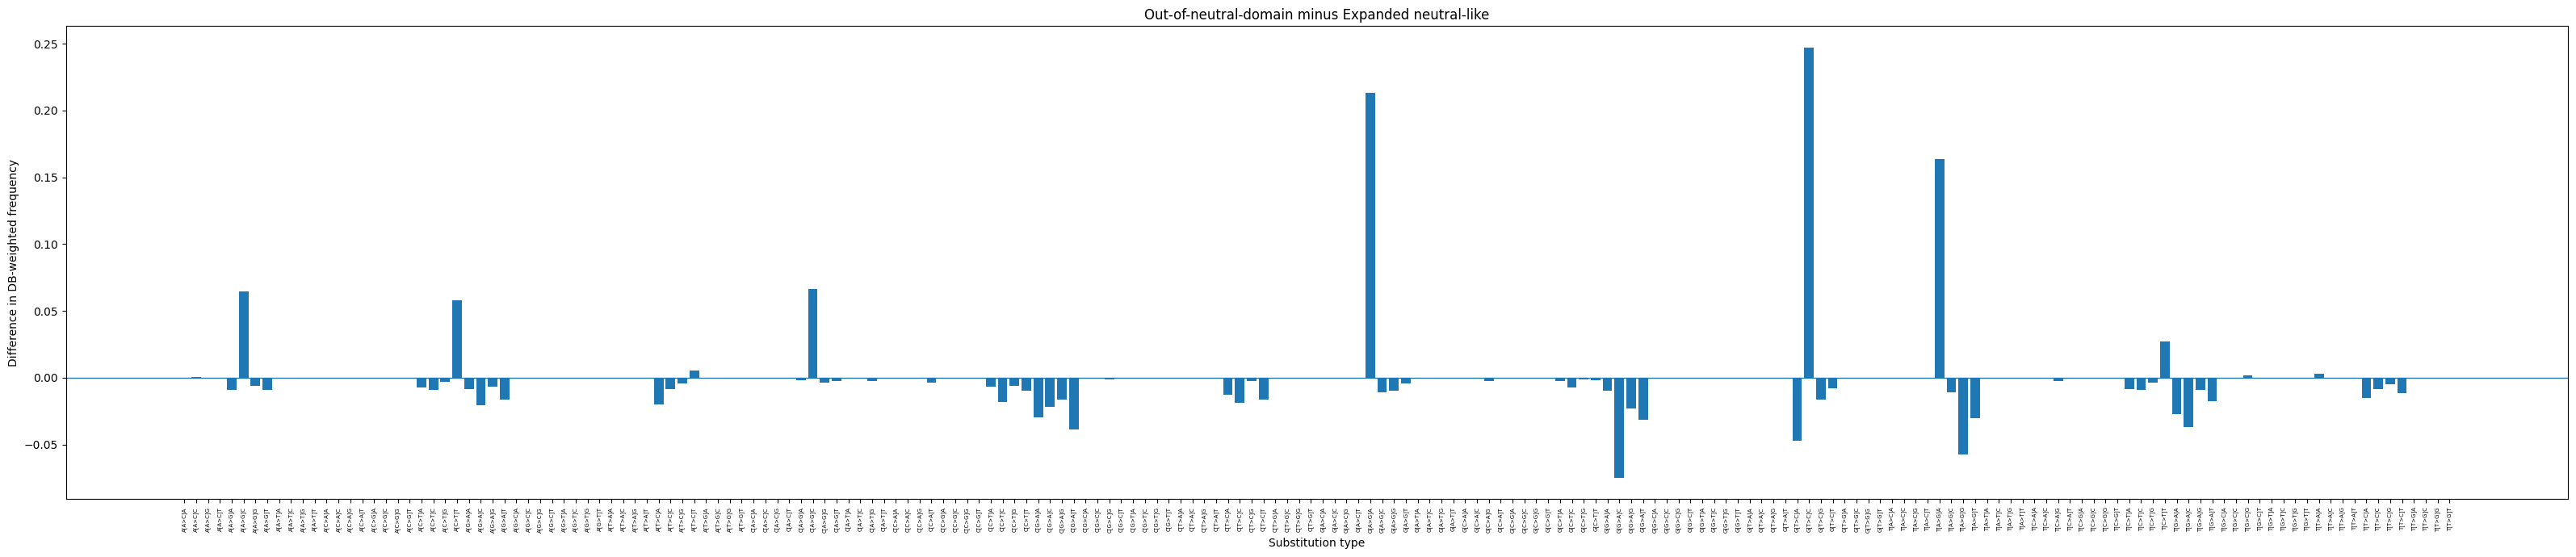

Figures saved to: ..\results\figures\mutation_spectra_192_T95


In [6]:
neutral_like_group = "expanded_neutral_like_T95"
out_of_domain_group = "unlabeled_out_of_neutral_domain_T95"

plot_single_spectrum(spectrum, neutral_like_group)
plot_single_spectrum(spectrum, out_of_domain_group)

plot_two_group_comparison(
    spectrum,
    group_1=neutral_like_group,
    group_2=out_of_domain_group,
)

plot_spectrum_difference(
    spectrum,
    reference_group=neutral_like_group,
    comparison_group=out_of_domain_group,
)

print("Figures saved to:", FIGURE_DIR)